Titanic Survival Prediction using Machine Learning

-Problem Statement

The objective of this project is to predict whether a passenger survived the Titanic disaster using demographic and travel-related information such as age, gender, passenger class, fare, and family size.

This project demonstrates a complete machine learning workflow including data preprocessing, exploratory data analysis, feature engineering, model training, hyperparameter tuning, and model evaluation.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Observations:

1. Age contains missing values.
2. Cabin contains many missing values.
3. Embarked contains a few missing values.
4. Dataset contains both numerical and categorical features.

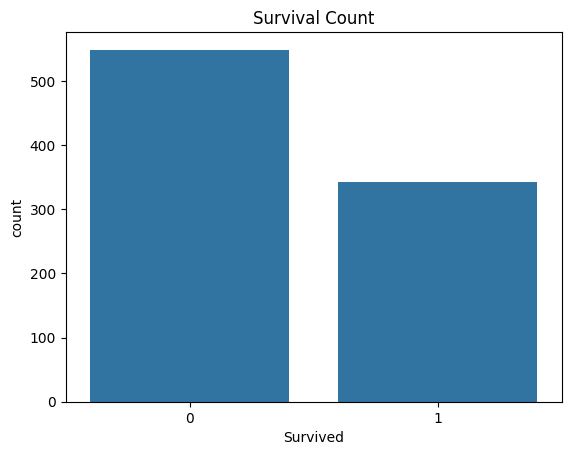

In [8]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

More passengers died than survived.

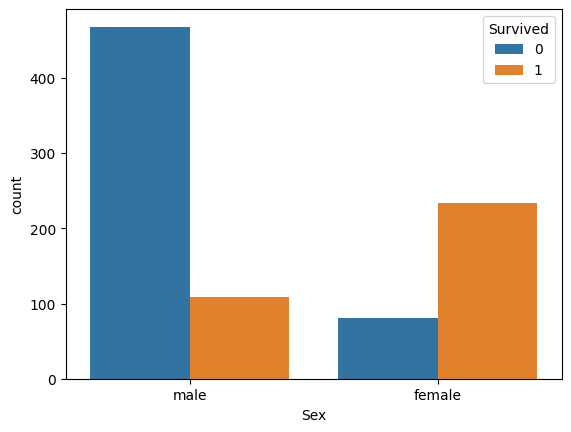

In [9]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)
plt.show()

Females had significantly higher survival rates.

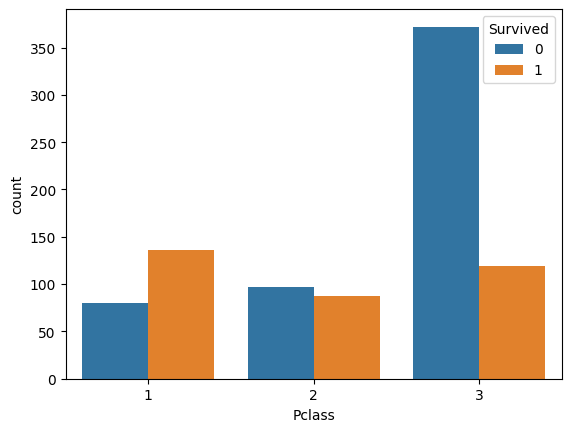

In [10]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)
plt.show()

First-class passengers survived more frequently.

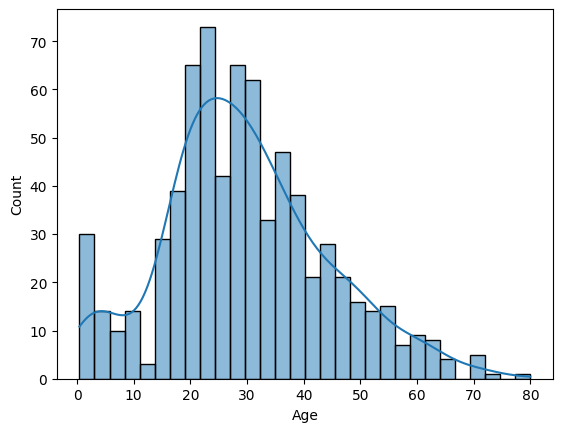

In [11]:
sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)
plt.show()

Most passengers were between 20 and 40 years old.

Performing data cleaning

In [12]:
df.drop(
    ['PassengerId','Ticket','Cabin'],
    axis=1,
    inplace=True
)

In [ ]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [ ]:
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [15]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Now we have no null values

In [17]:
df['FamilySize'] = (
    df['SibSp']
    + df['Parch']
    + 1
)

tells number of family members on board

In [18]:
df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

1 = traveling alone
0 = not alone

In [22]:
df['Title'] = df['Name'].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

In [23]:
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [25]:
df['Title'] = df['Title'].replace(
[
'Lady','Countess','Capt',
'Col','Don','Dr','Major',
'Rev','Sir','Jonkheer',
'Dona'
],
'Rare'
)

In [26]:
df.drop('Name', axis=1, inplace=True)

In [27]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(
    df['Sex']
)

df['Embarked'] = le.fit_transform(
    df['Embarked']
)

df['Title'] = le.fit_transform(
    df['Title']
)

Convert text into numbers.

In [28]:
X = df.drop(
    'Survived',
    axis=1
)

y = df['Survived']

separating passenger information and target

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

80% training
20% testing

Model 1 - Logistic Regression

In [30]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred_lr
    )
)

0.8044692737430168


Model 2 - Decision Tree

In [31]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred_dt
    )
)

0.7821229050279329


Model 3 - Random Forest

In [32]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred_rf
    )
)

0.8435754189944135


Comapring models

In [33]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.843575
0,Logistic Regression,0.804469
1,Decision Tree,0.782123


Hyperparameter Tuning

In [34]:
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    params,
    cv=5
)

grid.fit(
    X_train,
    y_train
)

grid.best_params_

{'max_depth': 5, 'n_estimators': 200}

Model performance improved after tuning.

In [35]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

In [36]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

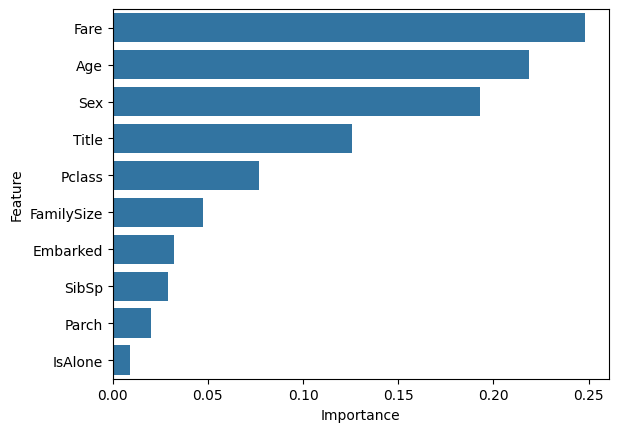

In [37]:
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.show()

Sex, Fare, Pclass and Age are among the most important predictors.

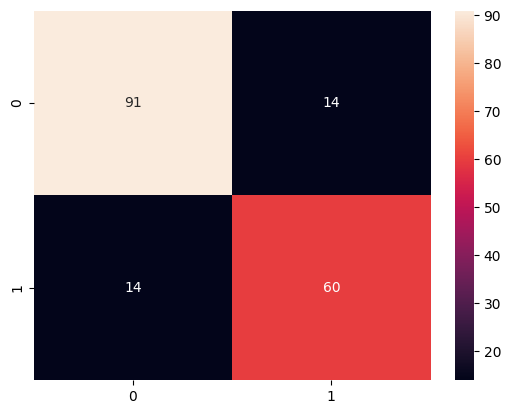

In [38]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()